## Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("../data/processed/final_dataset.csv")

# Display first 5 rows
df.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,day_of_week,is_weekend,season,is_holiday,holiday_name,promo_event,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2024-09-27,SKU0001,0.0,0.00,267.18,0,Decor,Lighting,2024-09-26,150.44,...,4,0,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
1,2024-09-28,SKU0001,2.0,518.94,259.47,0,Decor,Lighting,2024-09-26,150.44,...,5,1,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
2,2024-09-29,SKU0001,2.0,499.16,249.58,0,Decor,Lighting,2024-09-26,150.44,...,6,1,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
3,2024-09-30,SKU0001,2.0,489.22,244.61,0,Decor,Lighting,2024-09-26,150.44,...,0,0,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
4,2024-10-01,SKU0001,2.0,528.20,264.10,0,Decor,Lighting,2024-09-26,150.44,...,1,0,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0


In [3]:
df['date'] = pd.to_datetime(df['date'])

print(f" Loaded {len(df):,} records")
print(f" Date range: {df['date'].min()} to {df['date'].max()}")
print(f" {df['sku_id'].nunique()} unique SKU_id")
print(f" {df['category'].nunique()} categories")

df.head()

 Loaded 40,352 records
 Date range: 2023-07-13 00:00:00 to 2024-12-31 00:00:00
 149 unique SKU_id
 9 categories


,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,day_of_week,is_weekend,season,is_holiday,holiday_name,promo_event,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2024-09-27,SKU0001,0.0,0.00,267.18,0,Decor,Lighting,2024-09-26,150.44,...,4,0,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
1,2024-09-28,SKU0001,2.0,518.94,259.47,0,Decor,Lighting,2024-09-26,150.44,...,5,1,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
2,2024-09-29,SKU0001,2.0,499.16,249.58,0,Decor,Lighting,2024-09-26,150.44,...,6,1,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
3,2024-09-30,SKU0001,2.0,489.22,244.61,0,Decor,Lighting,2024-09-26,150.44,...,0,0,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
4,2024-10-01,SKU0001,2.0,528.20,264.10,0,Decor,Lighting,2024-09-26,150.44,...,1,0,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0


In [4]:
df.info()
df[['units_sold', 'revenue', 'unit_price', 'promo_flag']].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40352 entries, 0 to 40351
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            40352 non-null  datetime64[ns]
 1   sku_id          40352 non-null  object        
 2   units_sold      40352 non-null  float64       
 3   revenue         40352 non-null  float64       
 4   unit_price      40352 non-null  float64       
 5   promo_flag      40352 non-null  int64         
 6   category        40352 non-null  object        
 7   subcategory     40352 non-null  object        
 8   launch_date     40352 non-null  object        
 9   unit_cost       40352 non-null  float64       
 10  list_price      40352 non-null  float64       
 11  year            40352 non-null  int64         
 12  week            40352 non-null  int64         
 13  month           40352 non-null  int64         
 14  quarter         40352 non-null  int64         
 15  da

,units_sold,revenue,unit_price,promo_flag
count,40352.000000,4.035200e+04,40352.000000,40352.000000
mean,24.589215,9.566094e+04,3973.774921,0.179396
std,23.205521,1.800501e+05,4541.682672,0.383689
min,0.000000,0.000000e+00,60.760000,0.000000
25%,7.000000,8.731975e+03,686.357500,0.000000
50%,19.000000,3.377292e+04,2014.080000,0.000000
75%,35.000000,1.049565e+05,6440.340000,0.000000
max,259.000000,2.842104e+06,20951.210000,1.000000


In [5]:
df.isnull().sum().sort_values(ascending=False)

holiday_name      39265
promo_event       33113
units_sold            0
sku_id                0
unit_price            0
promo_flag            0
category              0
revenue               0
date                  0
launch_date           0
subcategory           0
unit_cost             0
list_price            0
month                 0
quarter               0
year                  0
week                  0
is_weekend            0
day_of_week           0
is_holiday            0
season                0
on_hand_units         0
on_order_units        0
lead_time_days        0
reorder_point         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,date,units_sold,revenue,unit_price,promo_flag,unit_cost,list_price,year,week,month,quarter,day_of_week,is_weekend,is_holiday,on_hand_units,on_order_units,lead_time_days,reorder_point
count,40352,40352.000000,4.035200e+04,40352.000000,40352.000000,40352.000000,40352.000000,40352.00000,40352.000000,40352.000000,40352.000000,40352.000000,40352.000000,40352.000000,40352.000000,40352.000000,40352.000000,40352.000000
mean,2024-06-30 07:27:57.954004736,24.589215,9.566094e+04,3973.774921,0.179396,2002.429927,4103.788525,2023.88464,32.090677,7.848657,2.925183,2.997224,0.286504,0.026938,1226.847195,414.028004,12.134814,912.791311
min,2023-07-13 00:00:00,0.000000,0.000000e+00,60.760000,0.000000,51.600000,88.150000,2023.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,18.000000
25%,2024-03-30 00:00:00,7.000000,8.731975e+03,686.357500,0.000000,454.510000,699.930000,2024.00000,21.000000,5.000000,2.000000,1.000000,0.000000,0.000000,504.000000,0.000000,7.000000,483.000000
50%,2024-07-21 00:00:00,19.000000,3.377292e+04,2014.080000,0.000000,1156.640000,2039.640000,2024.00000,35.000000,8.000000,3.000000,3.000000,0.000000,0.000000,939.000000,2.000000,11.000000,751.000000
75%,2024-10-20 00:00:00,35.000000,1.049565e+05,6440.340000,0.000000,2788.470000,6617.600000,2024.00000,45.000000,11.000000,4.000000,5.000000,1.000000,0.000000,1606.000000,441.000000,15.000000,1178.000000
max,2024-12-31 00:00:00,259.000000,2.842104e+06,20951.210000,1.000000,7990.730000,19954.980000,2024.00000,52.000000,12.000000,4.000000,6.000000,1.000000,1.000000,13079.000000,14990.000000,30.000000,4089.000000
std,NaN,23.205521,1.800501e+05,4541.682672,0.383689,2098.361729,4663.599964,0.31946,14.564419,3.300925,1.067046,2.004763,0.452133,0.161904,1131.207310,865.554951,6.507173,699.955408


## Sales Analysis

In [8]:
print("Total Revenue:", df["revenue"].sum())
print("Total Units Sold:", df["units_sold"].sum())

Total Revenue: 3860110277.39
Total Units Sold: 992224.0


sku_id
SKU0157    5.805385e+08
SKU0187    2.284846e+08
SKU0042    1.657215e+08
SKU0118    1.597373e+08
SKU0049    1.469337e+08
SKU0070    1.227168e+08
SKU0081    1.155191e+08
SKU0075    1.130923e+08
SKU0095    9.814673e+07
SKU0058    8.840456e+07
Name: revenue, dtype: float64


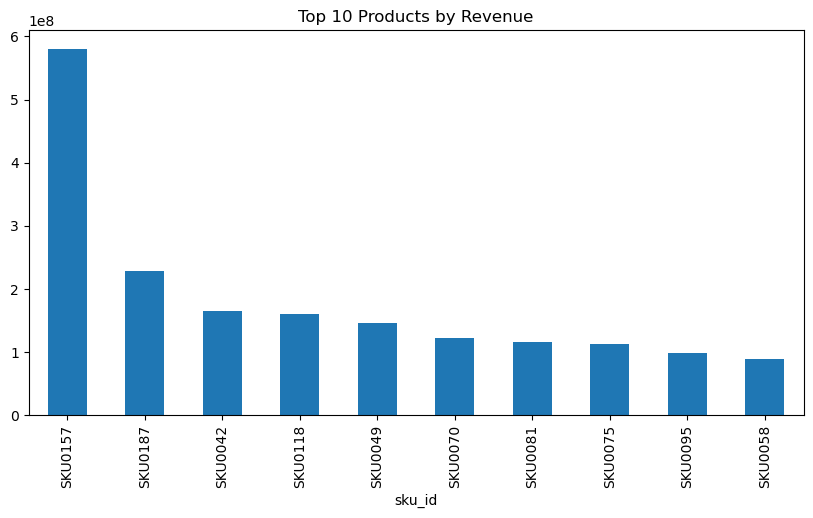

In [9]:
#Which products generate the highest revenue
top_products = (
    df.groupby("sku_id")["revenue"].sum().sort_values(ascending=False).head(10)
)

print(top_products)

top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.show()

category
Storage      1.122820e+09
Rugs         7.853918e+08
Bath         4.363746e+08
Bedding      4.098520e+08
Decor        3.760513e+08
Kitchen      3.652052e+08
Lighting     2.094491e+08
Furniture    1.347400e+08
Unknown      2.022663e+07
Name: revenue, dtype: float64


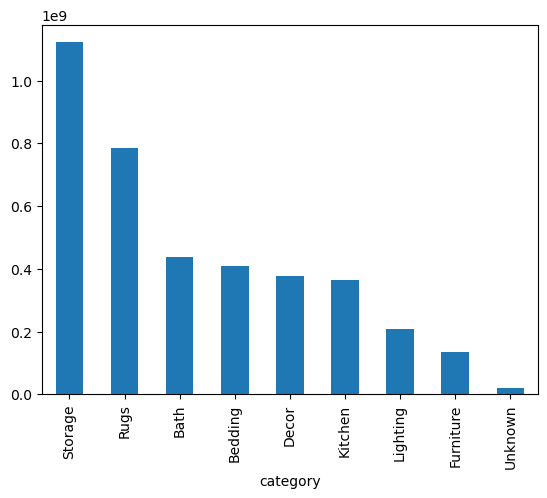

In [10]:
# Which categories generate the  revenue
category_sales = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
)



print(category_sales.head(10))
category_sales.plot(kind="bar")
plt.show()


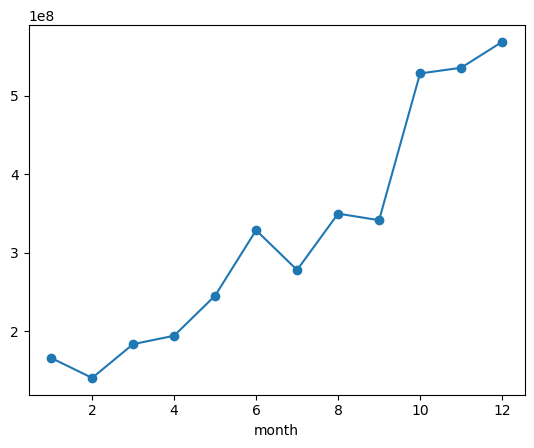

In [11]:
# Monthly Revenue Trend
monthly = (
    df.groupby("month")["revenue"]
      .sum()
)

monthly.plot(kind="line", marker="o")
plt.show()

## Inventory Analysis

In [12]:
# Which products have low inventory
low_stock = df[df["on_hand_units"] < df["reorder_point"]]

low_stock[["sku_id","on_hand_units","reorder_point"]].head(5)

,sku_id,on_hand_units,reorder_point
0,SKU0001,1389.0,1816.0
1,SKU0001,1389.0,1816.0
2,SKU0001,1389.0,1816.0
3,SKU0001,1389.0,1816.0
4,SKU0001,1389.0,1816.0


In [13]:
# Which products are overstocked
overstock = df[ df["on_hand_units"] >df["units_sold"] * 3]
overstock.head(5)

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,day_of_week,is_weekend,season,is_holiday,holiday_name,promo_event,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2024-09-27,SKU0001,0.0,0.00,267.18,0,Decor,Lighting,2024-09-26,150.44,...,4,0,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
1,2024-09-28,SKU0001,2.0,518.94,259.47,0,Decor,Lighting,2024-09-26,150.44,...,5,1,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
2,2024-09-29,SKU0001,2.0,499.16,249.58,0,Decor,Lighting,2024-09-26,150.44,...,6,1,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
3,2024-09-30,SKU0001,2.0,489.22,244.61,0,Decor,Lighting,2024-09-26,150.44,...,0,0,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0
4,2024-10-01,SKU0001,2.0,528.20,264.10,0,Decor,Lighting,2024-09-26,150.44,...,1,0,Fall,0,NaN,NaN,1389.0,3090.0,13.0,1816.0


In [14]:
# Average Lead Time by Category
df.groupby("category")["lead_time_days"].mean()

category
Bath          9.720038
Bedding       8.189763
Decor         7.088691
Furniture    19.709253
Kitchen      13.713257
Lighting     13.362315
Rugs         21.947773
Storage       8.499446
Unknown       3.625000
Name: lead_time_days, dtype: float64

## Promotion Analysis

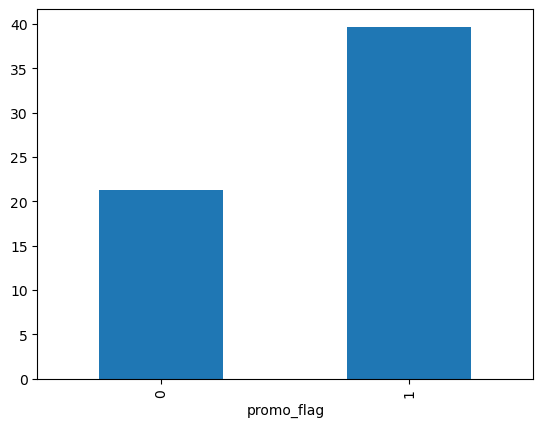

In [15]:
# Does promotion increase sales?
promo = (
    df.groupby("promo_flag")["units_sold"]
      .mean()
)
promo.plot(kind="bar")
plt.show()

In [16]:
# Revenue During Promotions
df.groupby("promo_flag")["revenue"].sum()

promo_flag
0    2.856876e+09
1    1.003234e+09
Name: revenue, dtype: float64

## Seasonal Analysis

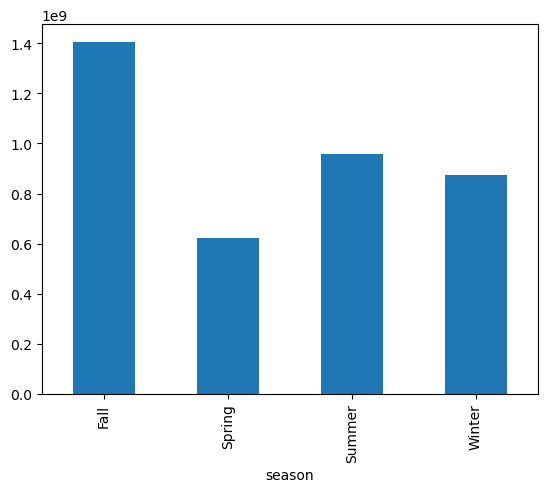

In [17]:
season_sales = (
    df.groupby("season")["revenue"]
      .sum()
)
season_sales.plot(kind="bar")
plt.show()

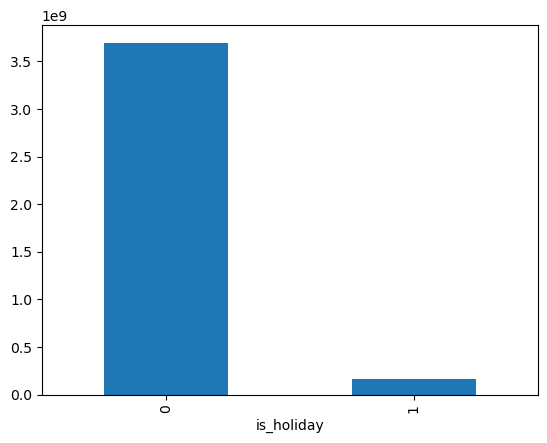

In [18]:
#Holiday vs Non-Holiday Sales
holiday = (df.groupby("is_holiday")["revenue"].sum())
holiday.plot(kind="bar")
plt.show()

    month       revenue
0       1  1.660846e+08
1       2  1.406394e+08
2       3  1.836554e+08
3       4  1.943407e+08
4       5  2.453700e+08
5       6  3.286644e+08
6       7  2.780720e+08
7       8  3.497951e+08
8       9  3.414151e+08
9      10  5.282368e+08
10     11  5.354646e+08
11     12  5.683722e+08


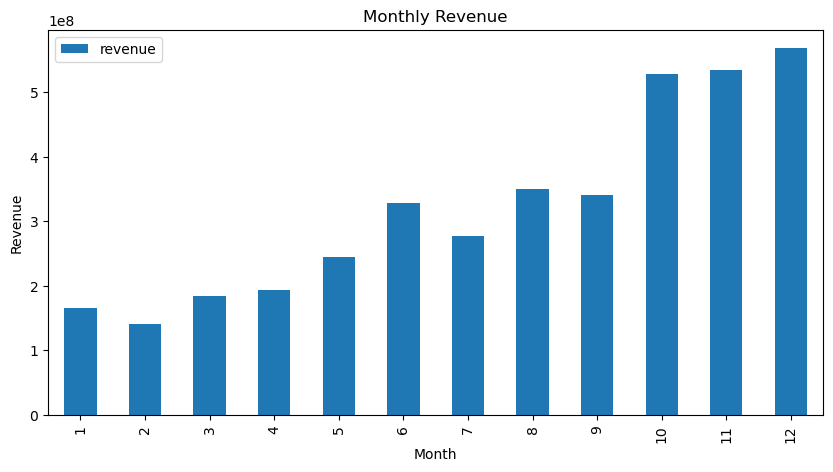

In [19]:
monthly_revenue = (
    df.groupby("month")["revenue"]
      .sum()
      .reset_index()
)

print(monthly_revenue)

monthly_revenue.plot(
    x="month",
    y="revenue",
    kind="bar",
    figsize=(10,5)
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Product Performance

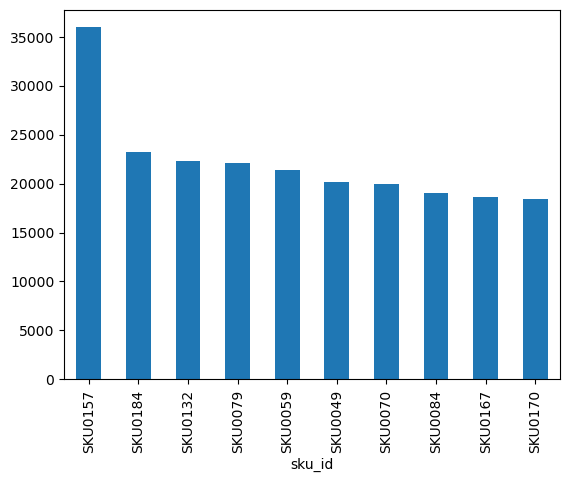

In [20]:
#Top 10 Selling SKUs
top_units = (df.groupby("sku_id")["units_sold"].sum().sort_values(ascending=False).head(10))
top_units.plot(kind="bar")
plt.show()

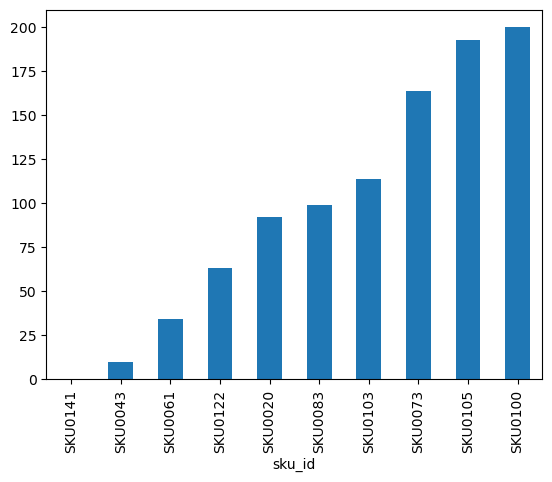

In [21]:
#bottom 10 Selling SKUs
bottom_units = (df.groupby("sku_id")["units_sold"].sum().sort_values(ascending=True).head(10))
bottom_units.plot(kind="bar")
plt.show()

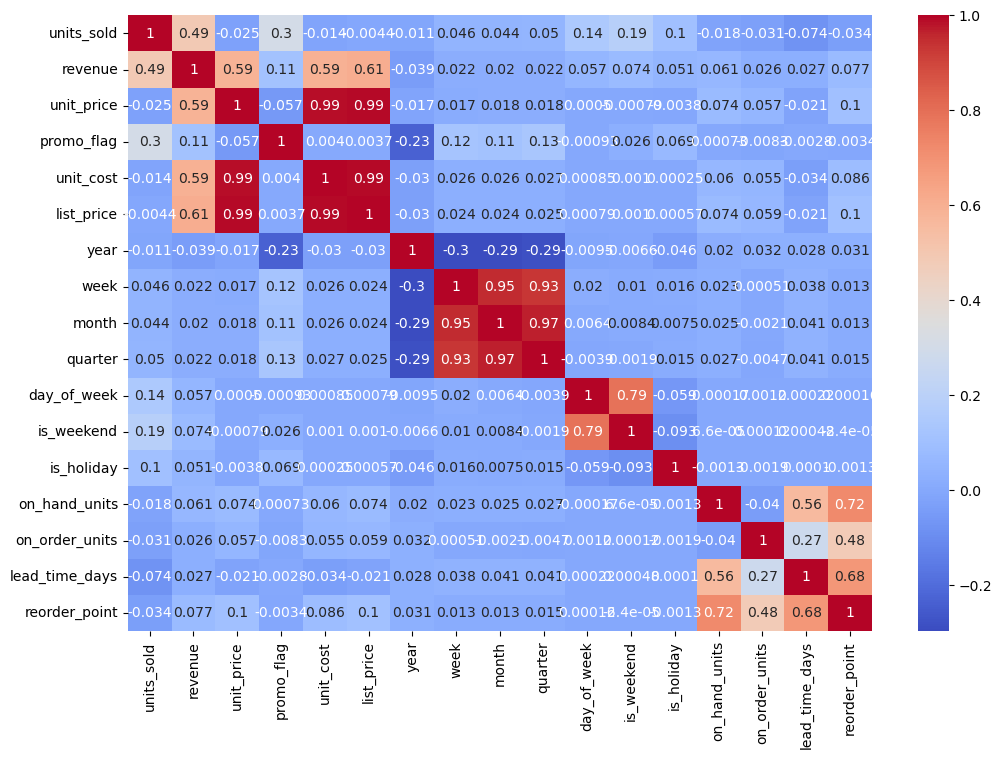

In [22]:
# Correlation
# Which numerical variables are related
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## overall conclusion 

In [23]:

# 1. sales are higher for a few top-selling products, so they should always be kept in stock.
# 2. Some products have very low sales and may need discounts or promotions.
# 3. Sales change by month and season, so inventory should be planned accordingly.
# 4. Promotions help increase product sales.
# 5. Products below the reorder point should be reordered to avoid stockouts.
# 6. Overstocked products should be cleared to reduce storage costs.
# 7. Categories with high revenue should receive more inventory and business focus.
# 8. Monitoring inventory and forecasting demand can improve customer satisfaction and reduce business losses.
# 9. Better inventory planning helps prevent both stock shortages and excess stock.
# 10. The analysis provides useful insights for making smarter inventory and sales decisions.  
